In [1]:
import fitz  # PyMuPDF
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import re
import os
import json
 
# Tesseract 경로 (Windows)
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
 
# 경로 설정
PDF_PATH = "../data/sample/2015개정경제수학-광주교육청.pdf"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# PDF 열기
doc = fitz.open(PDF_PATH)
print(f"총 페이지 수: {len(doc)}")

총 페이지 수: 198


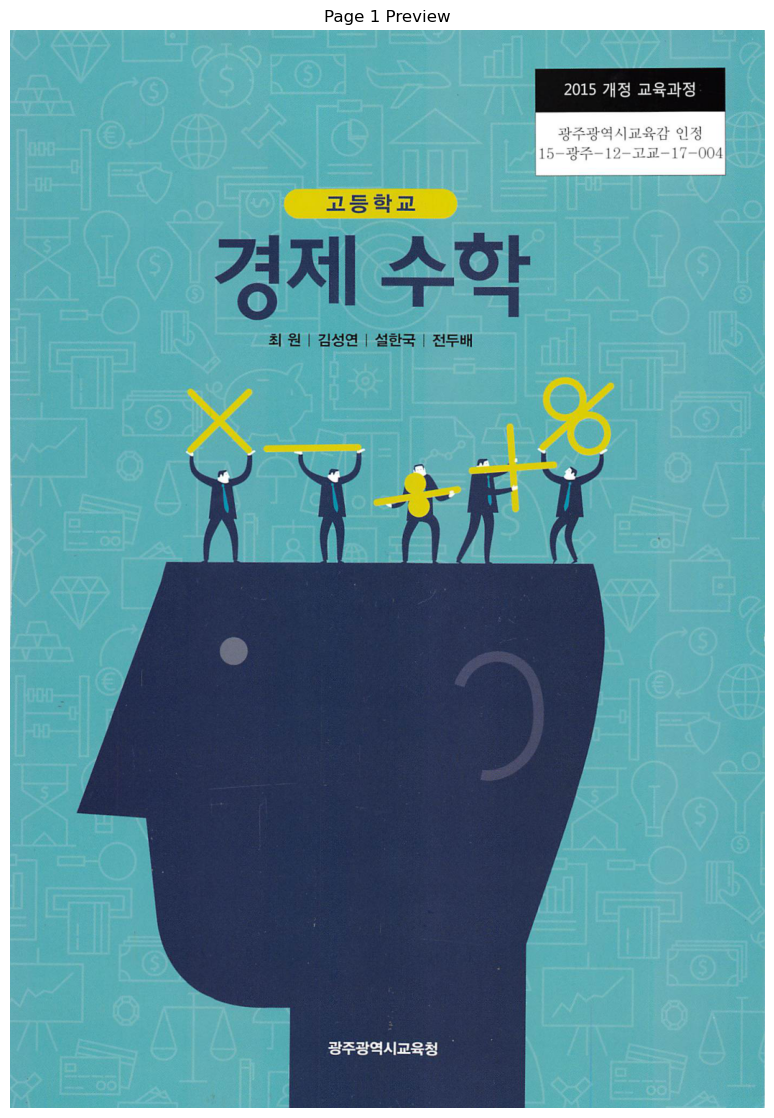

In [2]:
page = doc[0]
pix = page.get_pixmap(dpi=150)
img = Image.open(io.BytesIO(pix.tobytes("png")))
 
plt.figure(figsize=(10, 14))
plt.imshow(img)
plt.axis("off")
plt.title("Page 1 Preview")
plt.show()

In [3]:
def clean_ocr_text(text):
    """OCR 결과 후처리 함수"""
    # 한 글자씩 띄어진 공백 제거 (예: "경 제 생 활" → "경제생활")
    while re.search(r'([\uAC00-\uD7A3A-Za-z0-9]) ([\uAC00-\uD7A3A-Za-z0-9])', text):
        text = re.sub(r'([\uAC00-\uD7A3A-Za-z0-9]) ([\uAC00-\uD7A3A-Za-z0-9])', r'\1\2', text)
    # 마침표/쉼표 앞 공백 제거
    text = re.sub(r'\s+([.,!?])', r'\1', text)
    # 문장 시작 특수문자 정리
    text = re.sub(r'^[0@\\]\s*', '• ', text, flags=re.MULTILINE)
    # 여러 줄 공백 정리
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()
 
 
def ocr_page(doc, page_num, dpi=300):
    """단일 페이지 OCR 실행"""
    page = doc[page_num]
    pix = page.get_pixmap(dpi=dpi)
    img = Image.open(io.BytesIO(pix.tobytes("png")))
    text = pytesseract.image_to_string(img, lang='kor+eng')
    return clean_ocr_text(text)

In [4]:
test_pages = range(9, 14)  # 10~14페이지
results = []
 
for i in test_pages:
    print(f"[{i+1}페이지] 처리 중...")
    text = ocr_page(doc, i)
    results.append({
        "page_id": i + 1,
        "text": text
    })
    print(f"[{i+1}페이지] 완료 - {len(text)}자 추출")
 
print("\n전체 완료!")
 
# 결과 출력
for r in results:
    print(f"\n{'='*40}")
    print(f"[{r['page_id']}페이지]")
    print(r['text'][:200])

[10페이지] 처리 중...
[10페이지] 완료 - 104자 추출
[11페이지] 처리 중...
[11페이지] 완료 - 403자 추출
[12페이지] 처리 중...
[12페이지] 완료 - 729자 추출
[13페이지] 처리 중...
[13페이지] 완료 - 861자 추출
[14페이지] 처리 중...
[14페이지] 완료 - 918자 추출

전체 완료!

[10페이지]
• 경제생활에서기본연산의활용을이해한다.
• 경제생활에서수단위의활용을이해한다.
• 경제지표의의미와종류를이해한다.

• 환율의의미와환율계산법을이해한다.

• 훈세금의종류와MS계산법을이해한다.

[11페이지]
2016년BF예산어디에쓰이나
분야별재원배분 ※ ( ) 는전년대비증감률

( 단위 : 조원 )

자료 : 기획재정부

> 분야별예산배분

LED다음과He수와기호를가지고있다고하자.

• , 1, 2, 3, 4, 5, 6, 7, 8, 9
( ), +, -, × 훈층 ’ =

아래와같은활동으로연산에대한HSS해보자.
(1) 두개의연산만을사용하여73을만들어Sct.
(

[12페이지]
한교실에여학생과남학생의비율은1 :2라고한다.
교실의총학생수가30명일때, 남학생의수는몇Bola] 생각해보아라.

어떤현상을수학적으로표현할때종종비율이라는HSWAS사용한다. 비율의수학적의미는
어떤수가다른수의몇배인지를나타내는관계이다. 이러한비의값을비율8800) 이라고한다.

bolHeta2] 비는 @ : / 와BS꼴의표현이다. 여기서aS} HS각각비의항이라부르고,

[13페이지]
국민AS통계의SF지표는한나라경제의생산수준의변화를측정하는생산지표와국민
소득 ( 후생 ) 수준의변화를측정하는소득지표로구별된다..

국가의경제력과경제수준을나타내는대표적인지표로생산지표인GNP, GDPS} 소득지표
인GNI등이있다.
GNP?! 총생산, GrossNationalProduct )

1년동안국민들에의해최종적으로생산된물건과서비스의가치이다. 국민이외국에서생산

[14페이지]
GNI가계, 기업, 정부등한나라의모든경제주체가일정기간에생산한총부가가치를시
장가격으로평가하여합산한A

In [5]:
output_path = os.path.join(OUTPUT_DIR, "ocr_sample.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
 
print(f"저장 완료: {output_path}")

저장 완료: ../outputs\ocr_sample.json
